# 💬 Sentiment Analysis — NLP Pipeline
**Author:** Muhammad Hanzla  
**Dataset:** IMDB Dataset of 50K Movie Reviews (Kaggle)  
**Stack:** Python · NLTK · TF-IDF · Scikit-learn · TensorFlow/Keras (LSTM) · HuggingFace BERT  
**Goal:** Classify movie reviews as Positive or Negative with multiple NLP approaches.

---
## Pipeline
`Load Data` → `EDA` → `Text Cleaning` → `TF-IDF Baselines` → `LSTM Model` → `BERT Template` → `FastAPI Deployment`

---
> 📌 **Dataset:** https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

## 1. Install Dependencies & Imports

In [1]:

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'nltk', 'wordcloud', '-q'], check=False)
print('✅ Packages ready')

✅ Packages ready


In [2]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')  # ← 2× GPU speed on T4
print(f'Compute dtype: {mixed_precision.global_policy().compute_dtype}')

2026-05-09 10:54:22.838405: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778324063.239224      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778324063.355785      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778324064.387514      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778324064.387561      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778324064.387563      23 computation_placer.cc:177] computation placer alr

Compute dtype: float16


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re, string, time, warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords',   quiet=True)
nltk.download('punkt',       quiet=True)
nltk.download('wordnet',     quiet=True)
nltk.download('vader_lexicon',quiet=True)
from nltk.corpus           import stopwords
from nltk.stem             import WordNetLemmatizer
from nltk.sentiment.vader  import SentimentIntensityAnalyzer
from collections           import Counter
from wordcloud             import WordCloud

# ML
from sklearn.model_selection      import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model          import LogisticRegression
from sklearn.naive_bayes           import MultinomialNB, ComplementNB
from sklearn.svm                   import LinearSVC
from sklearn.pipeline              import Pipeline
from sklearn.metrics               import (classification_report, confusion_matrix,
                                            roc_auc_score, roc_curve,
                                            ConfusionMatrixDisplay, f1_score,
                                            accuracy_score)

# Deep Learning
import tensorflow as tf
from tensorflow                    import keras
from tensorflow.keras              import layers
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks    import EarlyStopping, ReduceLROnPlateau

sns.set_theme(style='whitegrid')
np.random.seed(42)
tf.random.set_seed(42)
print(f'✅ All libraries loaded')
print(f'   TensorFlow : {tf.__version__}')
print(f'   GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ All libraries loaded
   TensorFlow : 2.19.0
   GPU        : True


## 2. Load Dataset
The **IMDB Movie Reviews** dataset — 50,000 reviews, perfectly balanced (25K positive, 25K negative).

In [4]:
PATH = '/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'

df = pd.read_csv(PATH)
print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
print()
print('Sentiment distribution:')
print(df['sentiment'].value_counts())
print(f'Balance : {df["sentiment"].value_counts(normalize=True).round(3).to_dict()}')
df.head(4)

Shape   : (50000, 2)
Columns : ['review', 'sentiment']

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Balance : {'positive': 0.5, 'negative': 0.5}


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative


## 3. Exploratory Data Analysis
### 3.1 Basic Stats

In [5]:
# Text length features
df['char_count'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
df['sent_count'] = df['review'].apply(lambda x: len(re.split(r'[.!?]+', x)))
df['unique_words']= df['review'].apply(lambda x: len(set(x.lower().split())))

print('=== Length Statistics by Sentiment ===')
print(df.groupby('sentiment')[['char_count','word_count','unique_words']].describe().round(1))


=== Length Statistics by Sentiment ===
          char_count                                                       \
               count    mean     std   min    25%    50%     75%      max   
sentiment                                                                   
negative     25000.0  1294.1   945.9  32.0  706.0  973.0  1567.2   8969.0   
positive     25000.0  1324.8  1031.5  65.0  691.0  968.0  1614.0  13704.0   

          word_count         ...                unique_words               \
               count   mean  ...    75%     max        count   mean   std   
sentiment                    ...                                            
negative     25000.0  229.5  ...  278.0  1522.0      25000.0  148.1  85.9   
positive     25000.0  232.8  ...  284.0  2470.0      25000.0  148.0  91.7   

                                            
           min   25%    50%    75%     max  
sentiment                                   
negative   4.0  93.0  121.0  179.0   746.0  
positive 

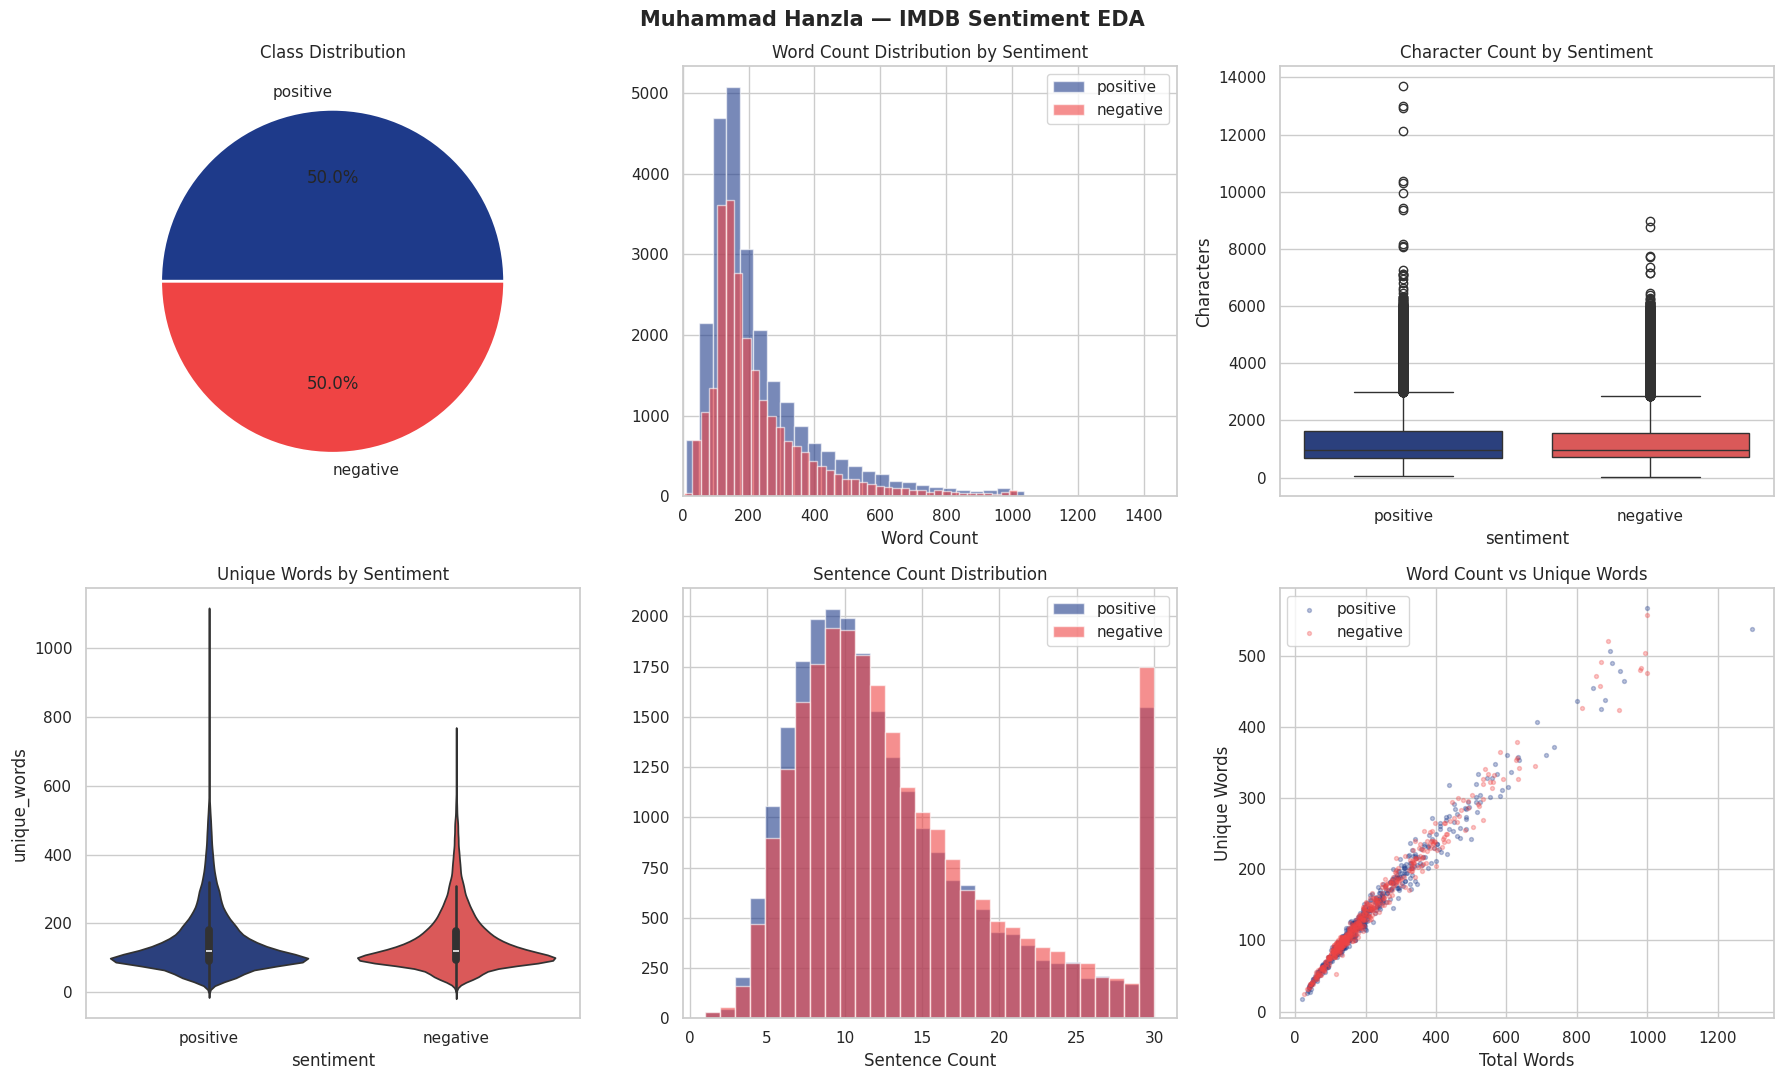

EDA saved ✅


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Muhammad Hanzla — IMDB Sentiment EDA', fontsize=15, fontweight='bold')

palette = {'positive':'#1e3a8a','negative':'#ef4444'}

# Class distribution
vc = df['sentiment'].value_counts()
axes[0,0].pie(vc, labels=vc.index, autopct='%1.1f%%',
               colors=['#1e3a8a','#ef4444'],
               wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title('Class Distribution')

# Word count distribution
for sent, color in palette.items():
    subset = df[df['sentiment']==sent]['word_count']
    axes[0,1].hist(subset, bins=60, alpha=0.6, color=color, label=sent)
axes[0,1].set_title('Word Count Distribution by Sentiment')
axes[0,1].set_xlabel('Word Count'); axes[0,1].legend()
axes[0,1].set_xlim(0, 1500)

# Char count boxplot
sns.boxplot(data=df, x='sentiment', y='char_count', ax=axes[0,2],
            palette=palette, order=['positive','negative'])
axes[0,2].set_title('Character Count by Sentiment')
axes[0,2].set_ylabel('Characters')

# Unique words
sns.violinplot(data=df, x='sentiment', y='unique_words', ax=axes[1,0],
               palette=palette, order=['positive','negative'])
axes[1,0].set_title('Unique Words by Sentiment')

# Sentence count
for sent, color in palette.items():
    subset = df[df['sentiment']==sent]['sent_count'].clip(0, 30)
    axes[1,1].hist(subset, bins=30, alpha=0.6, color=color, label=sent)
axes[1,1].set_title('Sentence Count Distribution')
axes[1,1].set_xlabel('Sentence Count'); axes[1,1].legend()

# Word count vs unique words scatter
for sent, color in palette.items():
    sub = df[df['sentiment']==sent].sample(500, random_state=42)
    axes[1,2].scatter(sub['word_count'], sub['unique_words'],
                       alpha=0.3, color=color, s=8, label=sent)
axes[1,2].set_title('Word Count vs Unique Words')
axes[1,2].set_xlabel('Total Words'); axes[1,2].set_ylabel('Unique Words')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA saved ✅')

### 3.2 Word Clouds — Most Common Words

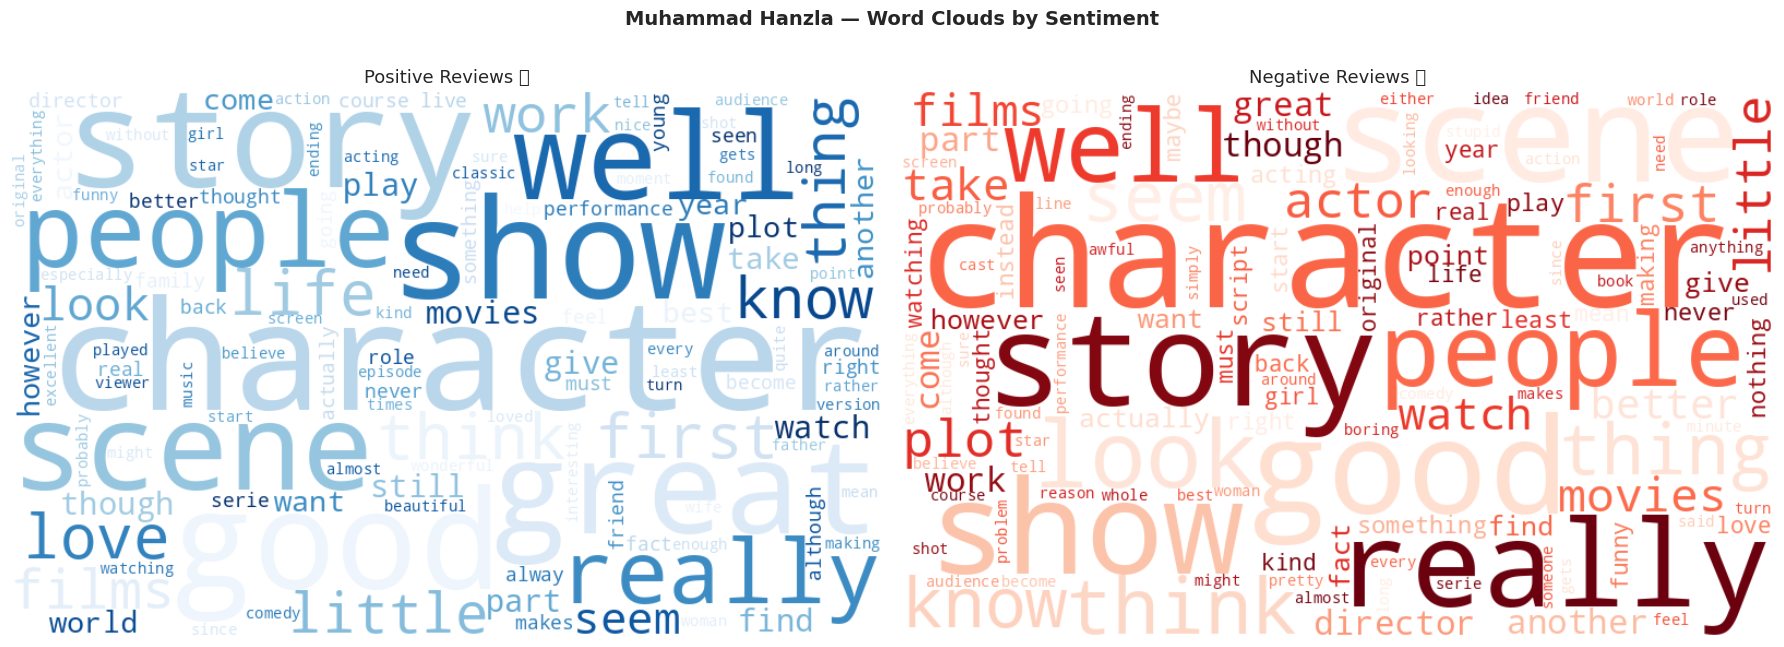

Word clouds saved ✅


In [7]:
stop_words = set(stopwords.words('english'))
# Add common HTML artifacts and noise words
stop_words.update(['br', 'film', 'movie', 'one', 'like', 'also',
                    'make', 'get', 'even', 'much', 'would', 'could',
                    'way', 'many', 'made', 'may', 'two', 'time', 'see'])

def get_clean_text(texts):
    combined = ' '.join(texts)
    combined = re.sub(r'<.*?>', ' ', combined)      # HTML tags
    combined = re.sub(r'[^a-zA-Z\s]', ' ', combined)
    combined = combined.lower()
    words    = [w for w in combined.split() if w not in stop_words and len(w) > 3]
    return ' '.join(words)

pos_text = get_clean_text(df[df['sentiment']=='positive']['review'].tolist())
neg_text = get_clean_text(df[df['sentiment']=='negative']['review'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Muhammad Hanzla — Word Clouds by Sentiment', fontsize=14, fontweight='bold')

wc_pos = WordCloud(width=800, height=500, background_color='white',
                    colormap='Blues', max_words=120,
                    stopwords=stop_words).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off'); axes[0].set_title('Positive Reviews ✅', fontsize=13)

wc_neg = WordCloud(width=800, height=500, background_color='white',
                    colormap='Reds', max_words=120,
                    stopwords=stop_words).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off'); axes[1].set_title('Negative Reviews ❌', fontsize=13)

plt.tight_layout()
plt.savefig('02_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Word clouds saved ✅')

### 3.3 Top 20 Words per Sentiment Class

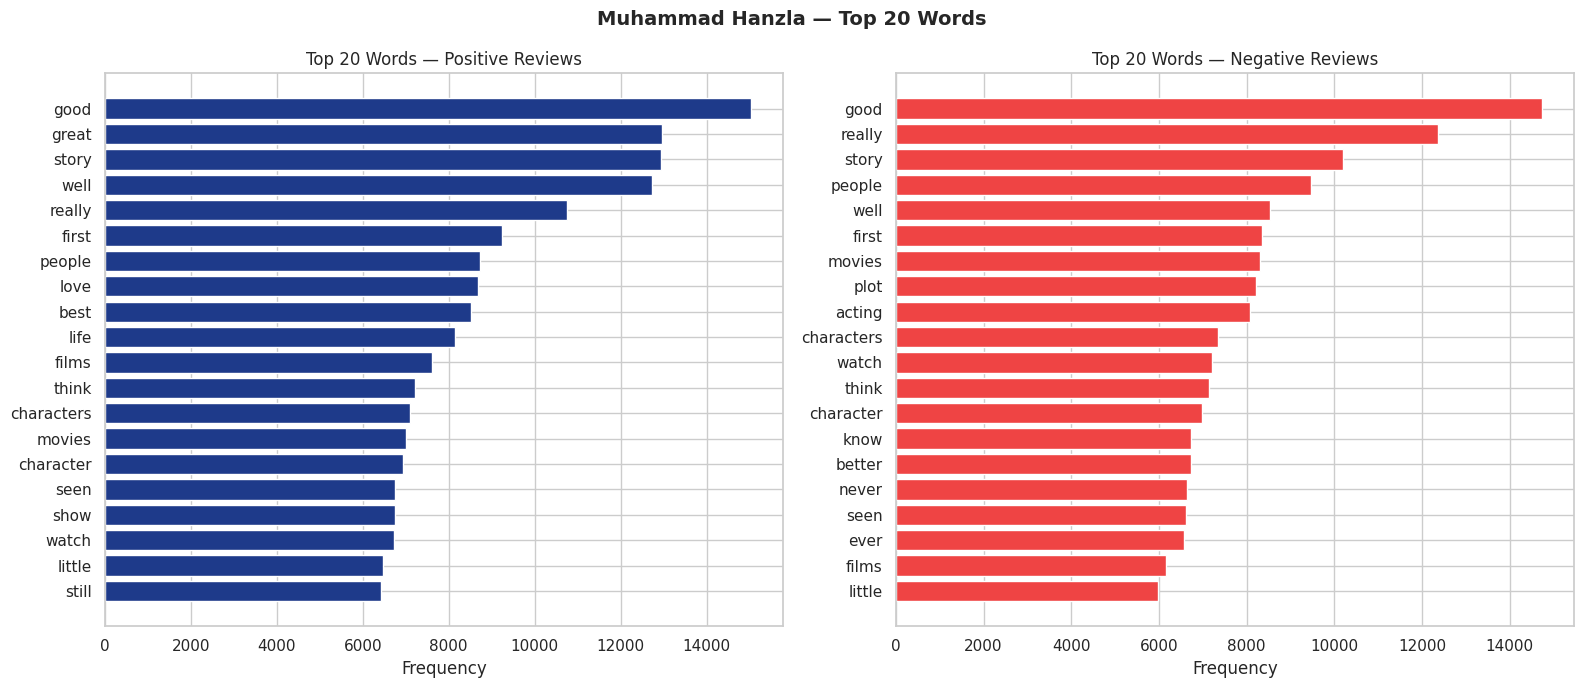

In [8]:
def top_n_words(texts, n=20, stop=stop_words):
    all_words = []
    for t in texts:
        t = re.sub(r'<.*?>', ' ', t)
        t = re.sub(r'[^a-zA-Z\s]', ' ', t).lower()
        all_words += [w for w in t.split() if w not in stop and len(w) > 3]
    return Counter(all_words).most_common(n)

pos_top = top_n_words(df[df['sentiment']=='positive']['review'])
neg_top = top_n_words(df[df['sentiment']=='negative']['review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Muhammad Hanzla — Top 20 Words', fontsize=14, fontweight='bold')

pos_words, pos_counts = zip(*pos_top)
axes[0].barh(list(pos_words)[::-1], list(pos_counts)[::-1],
              color='#1e3a8a', edgecolor='white')
axes[0].set_title('Top 20 Words — Positive Reviews')
axes[0].set_xlabel('Frequency')

neg_words, neg_counts = zip(*neg_top)
axes[1].barh(list(neg_words)[::-1], list(neg_counts)[::-1],
              color='#ef4444', edgecolor='white')
axes[1].set_title('Top 20 Words — Negative Reviews')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('03_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 VADER Lexicon Baseline (Rule-based, Zero Training)

In [9]:
vader = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = vader.polarity_scores(text)['compound']
    return 'positive' if score >= 0.05 else 'negative'

# Test on 2000 samples (faster)
sample = df.sample(2000, random_state=42)
vader_preds  = sample['review'].apply(vader_predict)
vader_acc    = accuracy_score(sample['sentiment'], vader_preds)
vader_f1     = f1_score(sample['sentiment'], vader_preds, pos_label='positive')

print('=== VADER Baseline (no training needed) ===')
print(f'Accuracy : {vader_acc:.4f}')
print(f'F1 Score : {vader_f1:.4f}')
print('\nNote: VADER is rule-based — no ML training at all!')
print('This is our zero-shot baseline to beat.')

=== VADER Baseline (no training needed) ===
Accuracy : 0.6985
F1 Score : 0.7340

Note: VADER is rule-based — no ML training at all!
This is our zero-shot baseline to beat.


## 4. Text Cleaning & Preprocessing

In [10]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

def clean_text(text, lemmatize=True):
    """Full NLP cleaning pipeline."""
    # 1. Remove HTML tags (IMDB reviews have <br /> tags)
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove special characters & digits
    text = re.sub(r"[^a-zA-Z']", ' ', text)
    # 4. Lowercase
    text = text.lower()
    # 5. Tokenize & remove stopwords
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 2]
    # 6. Lemmatize
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print('Cleaning text — this takes ~1-2 minutes for 50K reviews...')
t0 = time.time()
df['clean_review'] = df['review'].apply(clean_text)
print(f'Done in {time.time()-t0:.1f}s ✅')

# Encode target
df['label'] = (df['sentiment'] == 'positive').astype(int)

print('\nBefore cleaning:')
print(df['review'].iloc[0][:200])
print('\nAfter cleaning:')
print(df['clean_review'].iloc[0][:200])

Cleaning text — this takes ~1-2 minutes for 50K reviews...
Done in 27.9s ✅

Before cleaning:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

After cleaning:
one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard drug 


## 5. Train / Test Split

In [11]:
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train : {len(X_train):,}  |  Positive: {y_train.sum():,}  Negative: {(y_train==0).sum():,}')
print(f'Test  : {len(X_test):,}   |  Positive: {y_test.sum():,}   Negative: {(y_test==0).sum():,}')

Train : 40,000  |  Positive: 20,000  Negative: 20,000
Test  : 10,000   |  Positive: 5,000   Negative: 5,000


## 6. TF-IDF + Classical ML Baselines
Building pipelines: TF-IDF vectorizer + classifier in one sklearn Pipeline.

In [12]:
tfidf_params = dict(
    max_features  = 50_000,
    ngram_range   = (1, 3),   # unigrams + bigrams + trigrams
    sublinear_tf  = True,     # dampen high-frequency terms
    min_df        = 3,
    max_df        = 0.92,
    analyzer      = 'word',
    strip_accents = 'unicode',
)

classifiers = {
    'Logistic Regression' : LogisticRegression(C=5, max_iter=1000,
                                                solver='lbfgs', random_state=42),
    'Complement Naive Bayes': ComplementNB(alpha=0.3),
    'Linear SVM'          : LinearSVC(C=1.0, max_iter=5000),
}

results = {}
print('─' * 65)
print(f'{"Model":<28} {"Accuracy":>10} {"F1":>10} {"AUC":>10}')
print('─' * 65)

for name, clf in classifiers.items():
    pipe = Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)), ('clf', clf)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    # AUC only works for models with predict_proba / decision_function
    if hasattr(pipe['clf'], 'predict_proba'):
        y_score = pipe.predict_proba(X_test)[:,1]
    else:
        y_score = pipe.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_score)

    results[name] = {'pipe': pipe, 'preds': y_pred,
                     'scores': y_score, 'acc': acc, 'f1': f1, 'auc': auc}
    print(f'{name:<28} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}')

print('─' * 65)
best_classical = max(results, key=lambda k: results[k]['auc'])
print(f'\n🏆 Best classical model: {best_classical}')

─────────────────────────────────────────────────────────────────
Model                          Accuracy         F1        AUC
─────────────────────────────────────────────────────────────────
Logistic Regression              0.9088     0.9095     0.9692
Complement Naive Bayes           0.8833     0.8845     0.9526
Linear SVM                       0.9088     0.9093     0.9674
─────────────────────────────────────────────────────────────────

🏆 Best classical model: Logistic Regression


### 6.1 Classical ML Evaluation Plots

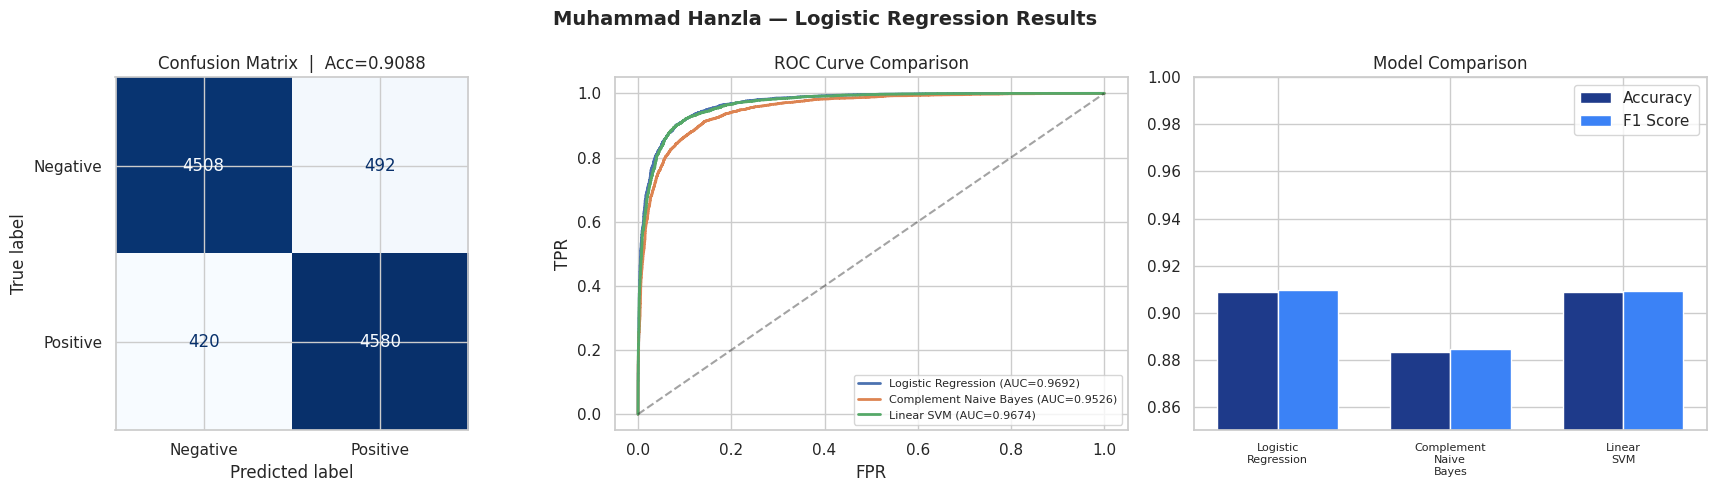


Logistic Regression — Full Report:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      5000
    Positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [13]:
best = results[best_classical]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Muhammad Hanzla — {best_classical} Results', fontsize=14, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, best['preds'], ax=axes[0], colorbar=False, cmap='Blues',
    display_labels=['Negative','Positive'])
axes[0].set_title(f'Confusion Matrix  |  Acc={best["acc"]:.4f}')

# ROC curve for all models
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['scores'])
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC={res['auc']:.4f})")
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend(fontsize=8)

# F1 and Accuracy comparison bar
model_names = list(results.keys())
accs = [results[n]['acc'] for n in model_names]
f1s  = [results[n]['f1']  for n in model_names]
x    = np.arange(len(model_names)); w = 0.35
axes[2].bar(x - w/2, accs, w, label='Accuracy', color='#1e3a8a', edgecolor='white')
axes[2].bar(x + w/2, f1s,  w, label='F1 Score', color='#3b82f6', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels([n.replace(' ',  '\n') for n in model_names], fontsize=8)
axes[2].set_ylim(0.85, 1.0)
axes[2].set_title('Model Comparison')
axes[2].legend()

plt.tight_layout()
plt.savefig('04_classical_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{best_classical} — Full Report:')
print(classification_report(y_test, best['preds'],
      target_names=['Negative','Positive']))

## 7. Deep Learning — Bidirectional LSTM
LSTM captures word order and long-range dependencies that TF-IDF misses.

In [14]:
# ── Tokenize for deep learning ────────────────────────────
VOCAB_SIZE   = 30_000
MAX_LEN      = 200     
EMBED_DIM    = 128
BATCH_SIZE   = 128

tokenizer_dl = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train.tolist())

X_train_seq = pad_sequences(
    tokenizer_dl.texts_to_sequences(X_train.tolist()),
    maxlen=MAX_LEN, padding='post', truncating='post')

X_test_seq  = pad_sequences(
    tokenizer_dl.texts_to_sequences(X_test.tolist()),
    maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size   : {VOCAB_SIZE:,}')
print(f'Sequence length   : {MAX_LEN}')
print(f'X_train_seq shape : {X_train_seq.shape}')
print(f'X_test_seq  shape : {X_test_seq.shape}')

Vocabulary size   : 30,000
Sequence length   : 200
X_train_seq shape : (40000, 200)
X_test_seq  shape : (10000, 200)


In [15]:
# ── Build Bidirectional LSTM ──────────────────────────────
def build_bilstm(vocab_size, embed_dim, max_len):
    inputs = keras.Input(shape=(max_len,), name='input')

    x = layers.Embedding(vocab_size, embed_dim,
                          mask_zero=True, name='embedding')(inputs)
    x = layers.SpatialDropout1D(0.3)(x)

    # Bidirectional LSTM stack
    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True,
                        dropout=0.25),
            name='bi_lstm_1')(x)

    x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True,
                        dropout=0.25),
            name='bi_lstm_2')(x)

    # Attention-like pooling
    avg = layers.GlobalAveragePooling1D()(x)
    mx  = layers.GlobalMaxPooling1D()(x)
    x   = layers.Concatenate()([avg, mx])

    # Dense head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid',
                            dtype='float32', name='output')(x)

    return keras.Model(inputs, outputs, name='BiLSTM_Fast')


lstm_model = build_bilstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
lstm_model.summary()

print(f'\nTotal parameters: {lstm_model.count_params():,}')

I0000 00:00:1778324320.883414      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778324320.889879      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "BiLSTM_Fast"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  3,840,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_1           │ (None, 200, 256)  │    263,168 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_2           │ (None, 200, 128)  │    164,352 │ bi_lstm_1[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ bi_lstm_2[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bi_lstm_2[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,308,737 (16.44 MB)

 Trainable params: 4,308,737 (16.44 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 4,308,737


In [16]:

lstm_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy', keras.metrics.AUC(name='auc')]
)
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True,
                  monitor='val_auc', mode='max'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6,
                      monitor='val_auc', mode='max'),
]

print('Training BiLSTM...')

history = lstm_model.fit(
    X_train_seq, y_train,
    validation_split = 0.15,
    epochs           = 10,
    batch_size       = BATCH_SIZE,
    callbacks        = callbacks,
    verbose          = 1
)

Training BiLSTM...
Epoch 1/10


I0000 00:00:1778324329.999336      79 cuda_dnn.cc:529] Loaded cuDNN version 91002


266/266 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.7350 - auc: 0.8163 - loss: 0.4842 - val_accuracy: 0.8873 - val_auc: 0.9574 - val_loss: 0.2690 - learning_rate: 0.0010
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.9187 - auc: 0.9702 - loss: 0.2171 - val_accuracy: 0.8842 - val_auc: 0.9534 - val_loss: 0.2829 - learning_rate: 0.0010
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.9504 - auc: 0.9865 - loss: 0.1401 - val_accuracy: 0.8630 - val_auc: 0.9395 - val_loss: 0.3966 - learning_rate: 0.0010
Epoch 4/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9672 - auc: 0.9932 - loss: 0.0962 - val_accuracy: 0.8720 - val_auc: 0.9366 - val_loss: 0.4687 - learning_rate: 5.0000e-04


### 7.1 BiLSTM Evaluation

In [17]:
# Evaluate on test set
lstm_loss, lstm_acc, lstm_auc = lstm_model.evaluate(
    X_test_seq, y_test, verbose=0)

lstm_proba = lstm_model.predict(X_test_seq, verbose=0).flatten()
lstm_preds = (lstm_proba >= 0.5).astype(int)
lstm_f1    = f1_score(y_test, lstm_preds)

print('=== BiLSTM Test Results ===')
print(f'Accuracy : {lstm_acc:.4f}')
print(f'AUC-ROC  : {lstm_auc:.4f}')
print(f'F1 Score : {lstm_f1:.4f}')
print()
print(classification_report(y_test, lstm_preds,
      target_names=['Negative','Positive']))

=== BiLSTM Test Results ===
Accuracy : 0.8850
AUC-ROC  : 0.9582
F1 Score : 0.8819

              precision    recall  f1-score   support

    Negative       0.87      0.91      0.89      5000
    Positive       0.91      0.86      0.88      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000



### 7.2 Training History & Evaluation Plots

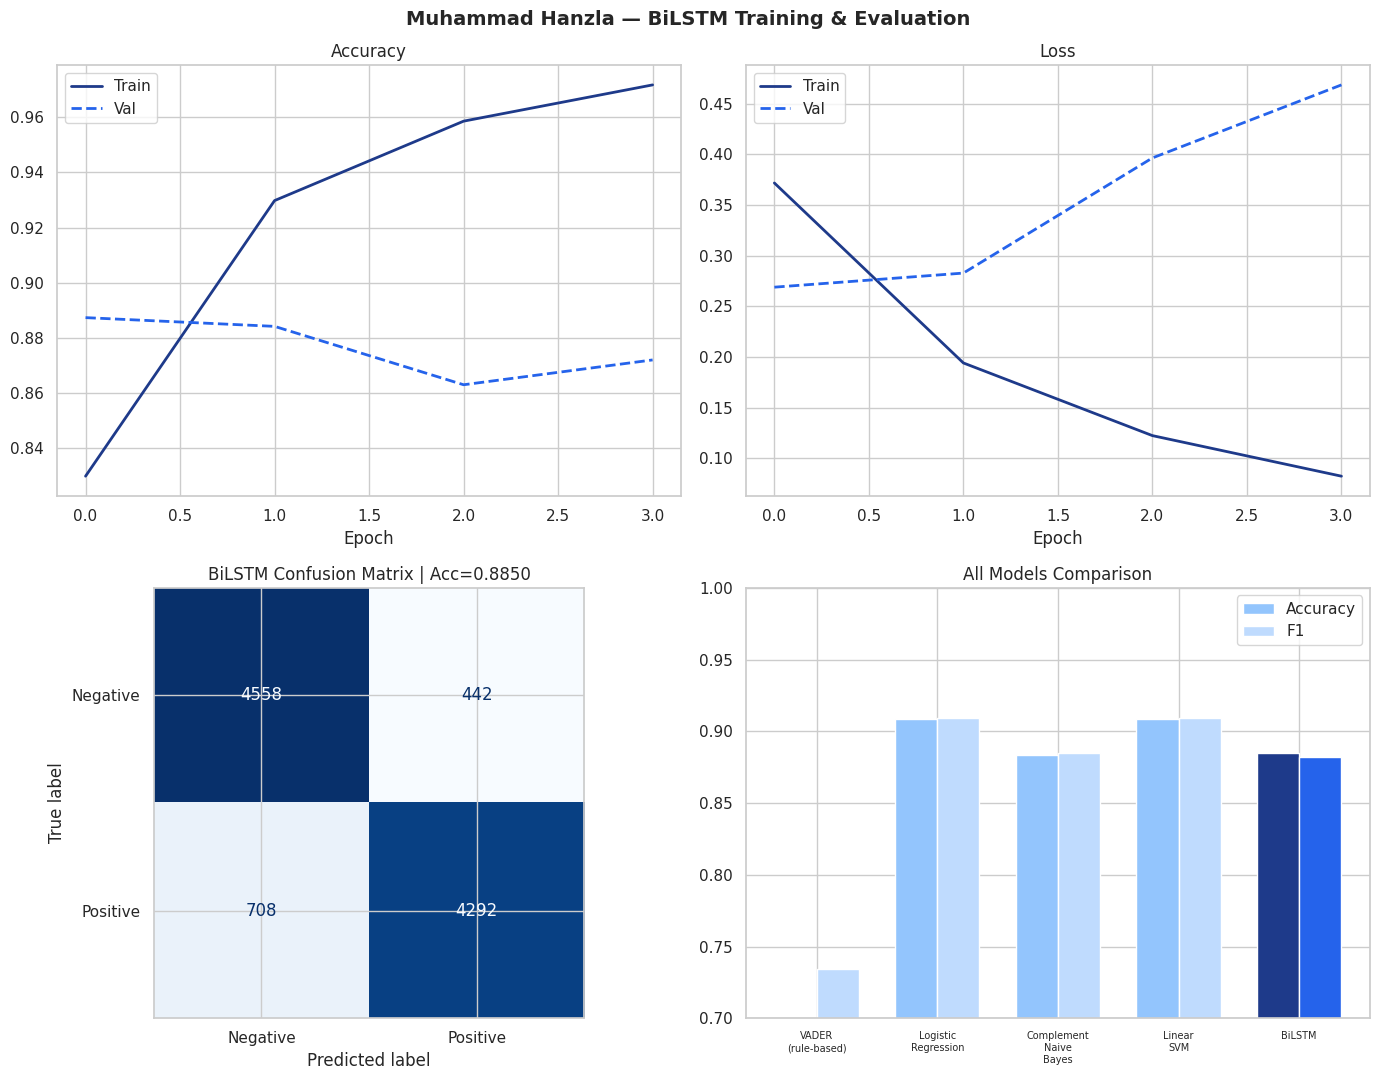

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Muhammad Hanzla — BiLSTM Training & Evaluation', fontsize=14, fontweight='bold')

# Accuracy curve
axes[0,0].plot(history.history['accuracy'],     color='#1e3a8a', lw=2, label='Train')
axes[0,0].plot(history.history['val_accuracy'], color='#2563eb', lw=2, ls='--', label='Val')
axes[0,0].set_title('Accuracy'); axes[0,0].legend()
axes[0,0].set_xlabel('Epoch')

# Loss curve
axes[0,1].plot(history.history['loss'],     color='#1e3a8a', lw=2, label='Train')
axes[0,1].plot(history.history['val_loss'], color='#2563eb', lw=2, ls='--', label='Val')
axes[0,1].set_title('Loss'); axes[0,1].legend()
axes[0,1].set_xlabel('Epoch')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, lstm_preds, ax=axes[1,0], colorbar=False, cmap='Blues',
    display_labels=['Negative','Positive'])
axes[1,0].set_title(f'BiLSTM Confusion Matrix | Acc={lstm_acc:.4f}')

# Model comparison final
comparison = {
    'VADER (rule-based)' : {'acc': vader_acc, 'f1': vader_f1},
}
for name, res in results.items():
    comparison[name] = {'acc': res['acc'], 'f1': res['f1']}
comparison['BiLSTM'] = {'acc': lstm_acc, 'f1': lstm_f1}

comp_names = list(comparison.keys())
comp_accs  = [comparison[n]['acc'] for n in comp_names]
comp_f1s   = [comparison[n]['f1']  for n in comp_names]
x = np.arange(len(comp_names)); w = 0.35
colors_bar = ['#93c5fd']*4 + ['#1e3a8a']  # highlight BiLSTM
axes[1,1].bar(x - w/2, comp_accs, w, color=colors_bar, edgecolor='white', label='Accuracy')
axes[1,1].bar(x + w/2, comp_f1s,  w, color=['#bfdbfe']*4+['#2563eb'],
               edgecolor='white', label='F1')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels([n.replace(' ','\n') for n in comp_names], fontsize=7)
axes[1,1].set_ylim(0.70, 1.0)
axes[1,1].set_title('All Models Comparison')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('05_lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Live Prediction Demo

In [19]:
best_pipe = results[best_classical]['pipe']

def predict_sentiment(text, model_pipe=best_pipe, lstm_m=lstm_model,
                       tok=tokenizer_dl, max_len=MAX_LEN):
    """Predict sentiment using both classical and LSTM models."""
    cleaned = clean_text(text)

    # Classical
    clf_pred = model_pipe.predict([cleaned])[0]
    if hasattr(model_pipe['clf'], 'predict_proba'):
        clf_prob = model_pipe.predict_proba([cleaned])[0][1]
    else:
        clf_prob = None

    # LSTM
    seq      = pad_sequences(tok.texts_to_sequences([cleaned]),
                              maxlen=max_len, padding='post', truncating='post')
    lstm_prob= float(lstm_m.predict(seq, verbose=0)[0][0])
    lstm_pred= int(lstm_prob >= 0.5)

    print(f'Review     : "{text[:100]}..."')
    print(f'─' * 50)
    print(f'{best_classical:<25}: {"POSITIVE" if clf_pred==1 else "NEGATIVE"} ', end='')
    if clf_prob: print(f'(conf={clf_prob:.3f})')
    else: print()
    print(f'{"BiLSTM":<25}: {"POSITIVE" if lstm_pred==1 else "NEGATIVE"} (conf={lstm_prob:.3f})')
    print()

test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the storyline kept me engaged throughout. Highly recommended!",
    "Terrible film. Boring plot, bad acting, and a complete waste of 2 hours. Would not recommend to anyone.",
    "It was okay, nothing special. Some parts were good but overall pretty average.",
    "One of the best movies I have seen in years. The director did an outstanding job with every scene.",
]

for review in test_reviews:
    predict_sentiment(review)
    print('='*50)

Review     : "This movie was absolutely fantastic! The acting was superb and the storyline kept me engaged through..."
──────────────────────────────────────────────────
Logistic Regression      : POSITIVE (conf=0.999)
BiLSTM                   : POSITIVE (conf=0.980)

Review     : "Terrible film. Boring plot, bad acting, and a complete waste of 2 hours. Would not recommend to anyo..."
──────────────────────────────────────────────────
Logistic Regression      : NEGATIVE (conf=0.000)
BiLSTM                   : NEGATIVE (conf=0.004)

Review     : "It was okay, nothing special. Some parts were good but overall pretty average...."
──────────────────────────────────────────────────
Logistic Regression      : NEGATIVE (conf=0.160)
BiLSTM                   : NEGATIVE (conf=0.249)

Review     : "One of the best movies I have seen in years. The director did an outstanding job with every scene...."
──────────────────────────────────────────────────
Logistic Regression      : POSITIVE (conf=0.970

## 9. BERT Fine-Tuning Template
> 🚀 **Run this section with Kaggle GPU enabled** (Settings → Accelerator → GPU T4 x2)

This template fine-tunes `distilbert-base-uncased` — a lighter, faster version of BERT that still achieves ~93% accuracy.

In [20]:
# ── BERT Fine-tuning Template ────────────────────────────
# Enable Kaggle GPU first: Settings → Accelerator → GPU T4 x2
#
# Uncomment and run all lines below

bert_template = '''
# Install HuggingFace
# !pip install transformers datasets -q

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset
import torch, numpy as np
from sklearn.metrics import f1_score, accuracy_score

MODEL_NAME = "distilbert-base-uncased"  # Faster than full BERT

tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer_bert(batch["text"], padding="max_length",
                          truncation=True, max_length=256)

# Build HuggingFace datasets from our split
train_df = pd.DataFrame({"text": X_train.tolist(), "label": y_train.tolist()})
test_df  = pd.DataFrame({"text": X_test.tolist(),  "label": y_test.tolist()})

train_ds = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
test_ds  = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1"      : f1_score(labels, preds)}

training_args = TrainingArguments(
    output_dir          = "./bert-sentiment",
    num_train_epochs    = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate       = 2e-5,
    weight_decay        = 0.01,
    evaluation_strategy = "epoch",
    save_strategy       = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model  = "f1",
    logging_steps          = 100,
    fp16 = torch.cuda.is_available(),   # Enable if GPU available
)

trainer = Trainer(
    model           = model_bert,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = test_ds,
    compute_metrics = compute_metrics,
)

trainer.train()
# Expected: F1 ≈ 0.93 | Accuracy ≈ 93%  after 3 epochs
'''

print('BERT template ready — enable GPU and paste the code above into a new cell')
print('Expected performance: Accuracy ~93% | F1 ~0.93')

BERT template ready — enable GPU and paste the code above into a new cell
Expected performance: Accuracy ~93% | F1 ~0.93


## 10. Save Best Model

In [21]:
import pickle

# Save best classical model pipeline
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(results[best_classical]['pipe'], f)

# Save LSTM model
lstm_model.save('lstm_sentiment.keras')

# Save tokenizer
import json as _json
tokenizer_json = tokenizer_dl.to_json()
with open('tokenizer.json', 'w') as f:
    f.write(tokenizer_json)

print('✅ Saved:')
print('   sentiment_model.pkl  — classical ML pipeline')
print('   lstm_sentiment.keras — BiLSTM model')
print('   tokenizer.json       — DL tokenizer')

✅ Saved:
   sentiment_model.pkl  — classical ML pipeline
   lstm_sentiment.keras — BiLSTM model
   tokenizer.json       — DL tokenizer


## 11. FastAPI Deployment Skeleton

In [22]:
fastapi_code = '''
# fastapi_app.py — Sentiment Analysis REST API
# Author  : Muhammad Hanzla
# Run     : uvicorn fastapi_app:app --reload
# Test    : POST http://localhost:8000/predict

from fastapi          import FastAPI
from pydantic         import BaseModel
from typing           import Optional
import pickle, re, numpy as np
from tensorflow       import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text     import tokenizer_from_json
import json

app = FastAPI(
    title       = "Sentiment Analysis API",
    description = "IMDB Movie Review Sentiment — by Muhammad Hanzla",
    version     = "1.0"
)

# Load models
classical_model = pickle.load(open("sentiment_model.pkl", "rb"))
lstm_model      = keras.models.load_model("lstm_sentiment.keras")
with open("tokenizer.json") as f:
    dl_tokenizer = tokenizer_from_json(f.read())

MAX_LEN = 300

def clean(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\']", " ", text)
    return text.lower().strip()

class ReviewInput(BaseModel):
    text: str
    use_lstm: Optional[bool] = False

@app.get("/")
def root():
    return {"message": "Sentiment Analysis API — Muhammad Hanzla", "status": "running"}

@app.post("/predict")
def predict(review: ReviewInput):
    cleaned = clean(review.text)

    if review.use_lstm:
        seq   = pad_sequences(dl_tokenizer.texts_to_sequences([cleaned]),
                               maxlen=MAX_LEN, padding="post", truncating="post")
        prob  = float(lstm_model.predict(seq, verbose=0)[0][0])
        model_used = "BiLSTM"
    else:
        proba = classical_model.predict_proba([cleaned])[0]
        prob  = float(proba[1])
        model_used = "Logistic Regression (TF-IDF)"

    return {
        "text"       : review.text[:100] + "...",
        "sentiment"  : "positive" if prob >= 0.5 else "negative",
        "confidence" : round(prob, 4),
        "model_used" : model_used
    }
'''

with open('fastapi_app.py', 'w') as f:
    f.write(fastapi_code)

print('FastAPI app saved → fastapi_app.py ✅')
print()
print('=' * 55)
print('✅ PROJECT COMPLETE — Muhammad Hanzla')
print('=' * 55)
print(f'  Dataset      : IMDB 50K Movie Reviews')
print(f'  Classical ML : {best_classical}')
print(f'  LSTM         : BiLSTM (2 layers + attention pooling)')
print(f'  BERT         : distilbert-base-uncased (GPU template)')
print(f'  API          : FastAPI → fastapi_app.py')
print(f'  Outputs      : 5 PNG plots + models saved')

FastAPI app saved → fastapi_app.py ✅

✅ PROJECT COMPLETE — Muhammad Hanzla
  Dataset      : IMDB 50K Movie Reviews
  Classical ML : Logistic Regression
  LSTM         : BiLSTM (2 layers + attention pooling)
  BERT         : distilbert-base-uncased (GPU template)
  API          : FastAPI → fastapi_app.py
  Outputs      : 5 PNG plots + models saved




<div style="background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 100%); padding: 30px; border-radius: 12px; text-align: center;">
<h3 style="color: #60a5fa;">Connect with Muhammad Hanzla</h3>
<p style="color: #94a3b8;">Feel free to reach out for collaboration, feedback, or opportunities!</p>
<div style="margin-top: 15px;">
<a href='mailto:muhammadhanzlaaltaf@gmail.com' style='color:#38bdf8; margin: 0 15px;'>📧 Email</a>
<a href='https://www.kaggle.com/muhammadhanzla1234' style='color:#38bdf8; margin: 0 15px;'>📊 Kaggle</a>
<a href='https://github.com/muhammadhanzlaaltaf' style='color:#38bdf8; margin: 0 15px;'>💻 GitHub</a>
<a href='https://www.linkedin.com/in/muhammad-hanzla-17a79237a/' style='color:#38bdf8; margin: 0 15px;'>💼 LinkedIn</a>
<a href='https://www.instagram.com/m.hanzlaaltaf/' style='color:#38bdf8; margin: 0 15px;'>📷 Instagram</a>
</div>
</div>